In [1]:
from models import *

import torch
import wandb
import os
from transformers import AutoTokenizer

from torchviz import make_dot

os.environ['WANDB_NOTEBOOK_NAME'] = 'model_training.ipynb'
wandb.login()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.environ['PATH'] += os.pathsep + 'C:\\Program Files\\Graphviz\\bin'

wandb: Currently logged in as: giacomoaru (giacomo-aru). Use `wandb login --relogin` to force relogin


In [2]:
print(device)
print(torch.cuda.get_device_name(device))

cuda
NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# selection of a pretrained transformer
model_name = "FacebookAI/xlm-roberta-base"
# correct tokenizer releted to the selected pretrained transformer
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_token_len = 125

test_tweet = 'This is a lovely tweet <3 #HiProf'

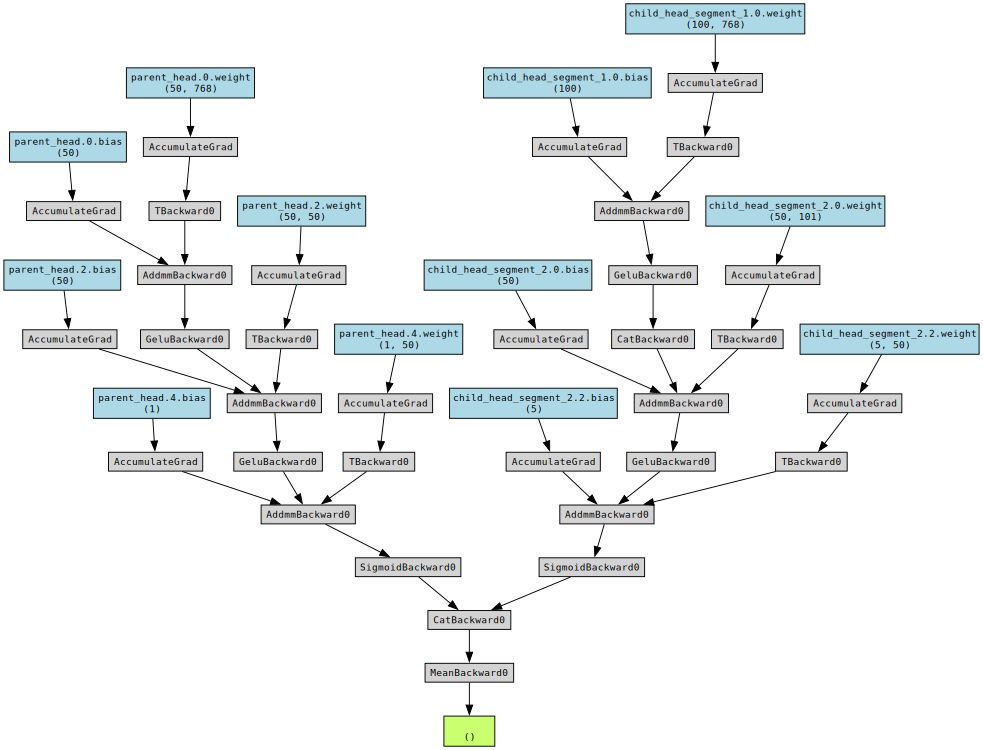

In [7]:
model = MultiLabelClassifierChain(model_name, 0.1, 100, 50).to(device)
model.freeze_pretrained()
model.train()
X = tokenizer('ABBOMBAZZZAAAA YOLO', padding="max_length", max_length=max_token_len,  return_tensors='pt', truncation=True).to(device)
y = model(X, torch.tensor([[1]], device=device))
make_dot(y.mean(), params=dict(model.named_parameters()))

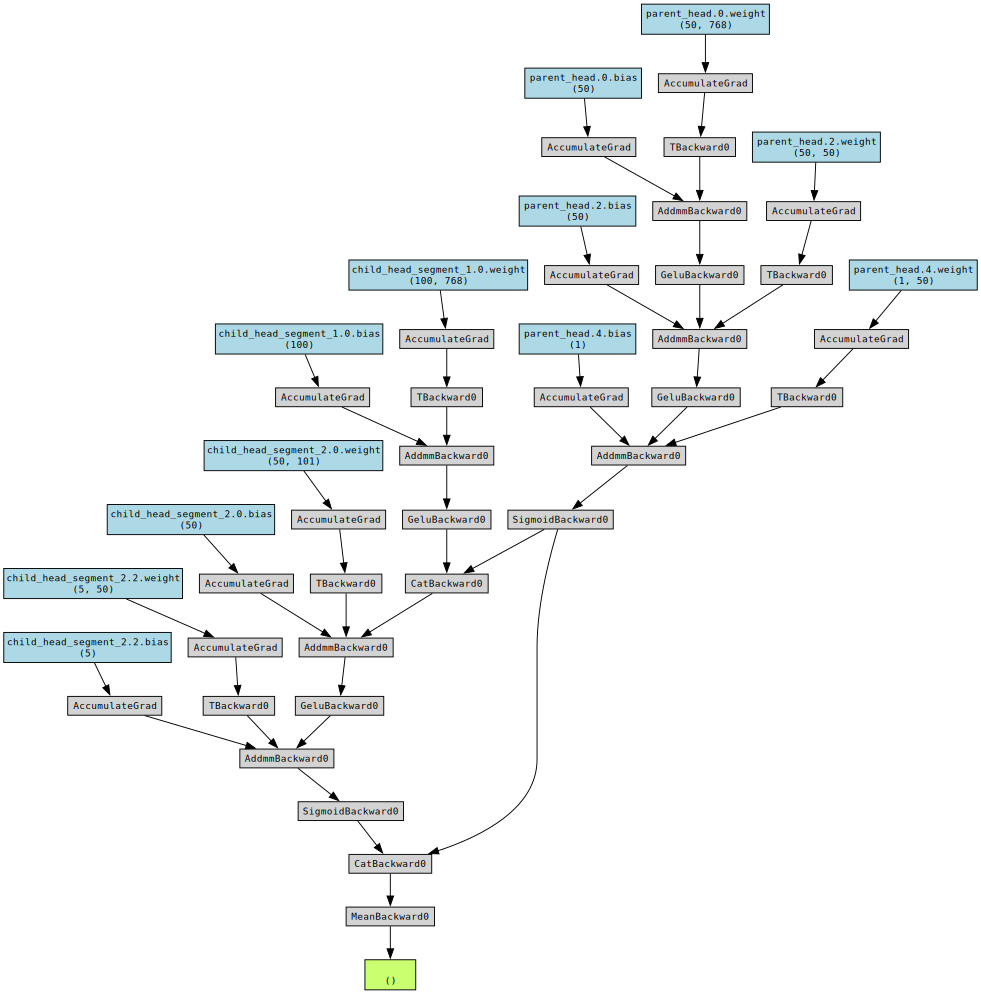

In [8]:
model = MultiLabelClassifierChain(model_name, 0.1, 100, 50).to(device)
model.freeze_pretrained()
model.eval()
X = tokenizer('ABBOMBAZZZAAAA YOLO', padding="max_length", max_length=max_token_len,  return_tensors='pt', truncation=True).to(device)
y = model(X, torch.tensor([[1]], device=device))
make_dot(y.mean(), params=dict(model.named_parameters()))

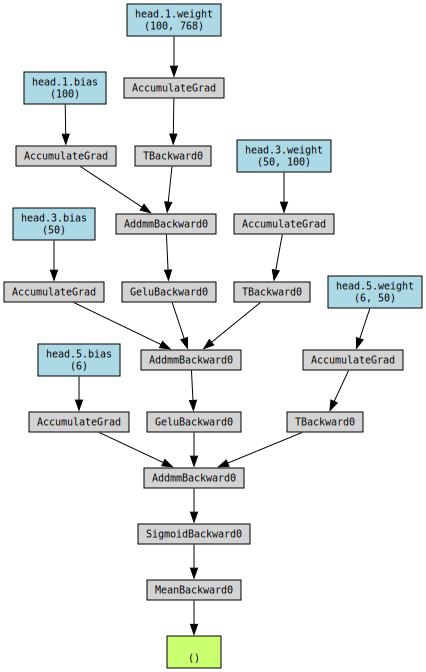

In [9]:
model = MultiLabelClassifier(model_name, 0.5, 100, 50).to(device)
model.freeze_pretrained()
model.train()
X = tokenizer('ABBOMBAZZZAAAA YOLO', padding="max_length", max_length=max_token_len,  return_tensors='pt', truncation=True).to(device)
y = model(X)
make_dot(y.mean(), params=dict(model.named_parameters()))